# Internship Data Analysis - Internshala 2025 ✅

**Data Source**: Scraped from Internshala portal in 2025  
**Dataset**: Internship opportunities across major Indian cities + work-from-home positions  
**Author**: *For complete scraping code and methodology, feel free to connect with me on LinkedIn*

### Project Overview

This notebook provides a comprehensive analysis of internship opportunities available on Internshala in 2025. The data was collected through web scraping and includes detailed information about:

- **Location-based internships**: Bangalore, Chennai, Delhi, Hyderabad, Jaipur, Kolkata, Mumbai, Pune
- **Remote opportunities**: Work-from-home internships
- **Key metrics**: Stipends, duration, skills required, company profiles, and more

Let's dive into the data and uncover some interesting insights! 🚀

In [137]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("📚 Libraries loaded successfully!")
print("🎨 Plotting style configured!")
print("=" * 50)

📚 Libraries loaded successfully!
🎨 Plotting style configured!


## 📂 Data Loading & First Look

Time to load our dataset and see what we're working with!

In [138]:
# Load the dataset
df = pd.read_csv('merged_internships_dataset.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

Dataset loaded successfully!
Shape: 8483 rows × 13 columns
Column Names:
 1. internship_id
 2. Date Time
 3. profile
 4. company
 5. Location
 6. Start Date
 7. Stipend
 8. Duration
 9. Apply by Date
10. Offer
11. Education
12. Skills
13. Perks


In [139]:
# Basic info about the dataset
print("Dataset Info:")
df.info()
print("\n" + "~"*80)

# Check for missing values
print("Missing Values:")
missing_vals = df.isnull().sum()
missing_percent = (missing_vals / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_vals,
    'Percentage': missing_percent.round(2)
}).sort_values('Missing Count', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8483 entries, 0 to 8482
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   internship_id  8483 non-null   object
 1   Date Time      8483 non-null   object
 2   profile        8483 non-null   object
 3   company        8483 non-null   object
 4   Location       8483 non-null   object
 5   Start Date     8483 non-null   object
 6   Stipend        8483 non-null   object
 7   Duration       8483 non-null   object
 8   Apply by Date  8483 non-null   object
 9   Offer          8483 non-null   object
 10  Education      8483 non-null   object
 11  Skills         8483 non-null   object
 12  Perks          8483 non-null   object
dtypes: object(13)
memory usage: 861.7+ KB

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Missing Values:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


## 🌍 Geographic Distribution Analysis

Let's see where most internships are concentrated. I'm curious to know which cities are offering the most opportunities!

Top 10 Internship Locations:
-----------------------------------
Work from home      : 2647 ( 31.2%)
Mumbai              :  971 ( 11.4%)
Delhi               :  938 ( 11.1%)
Bangalore           :  724 (  8.5%)
Chennai             :  556 (  6.6%)
Pune                :  428 (  5.0%)
Gurgaon             :  411 (  4.8%)
Noida               :  364 (  4.3%)
Hyderabad           :  232 (  2.7%)
Not Available       :  207 (  2.4%)


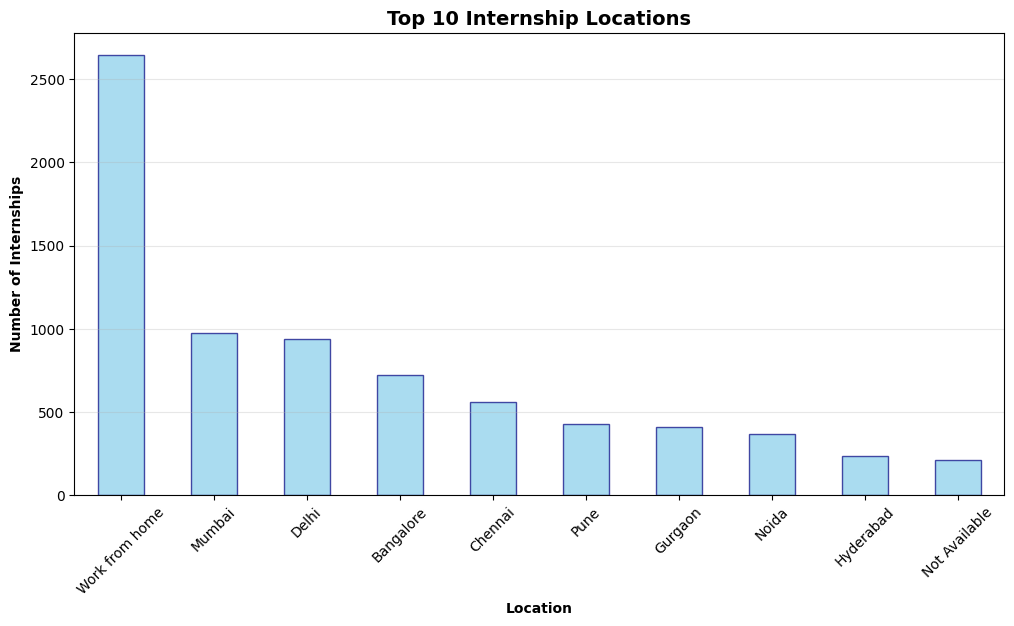

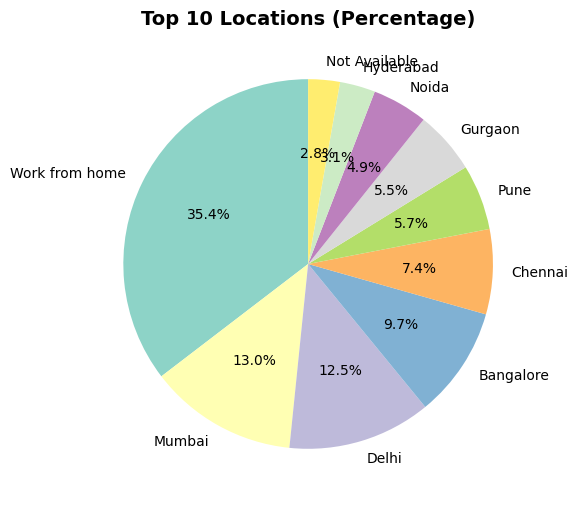

In [140]:
# Show top 10 location distribution
location_counts = df['Location'].value_counts()
top_10_locations = location_counts.head(10)
print("Top 10 Internship Locations:")
print("-" * 35)
for location, count in top_10_locations.items():
    percentage = (count / len(df)) * 100
    print(f"{location:<20}: {count:>4} ({percentage:5.1f}%)")

# Bar plot
top_10_locations.plot(kind='bar', color='skyblue', edgecolor='navy', alpha=0.7)
plt.title('Top 10 Internship Locations', fontsize=14, fontweight='bold')
plt.xlabel('Location', fontweight='bold')
plt.ylabel('Number of Internships', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(top_10_locations)))
plt.pie(top_10_locations.values, labels=top_10_locations.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
plt.title('Top 10 Locations (Percentage)', fontsize=14, fontweight='bold')
plt.show()


## 💰 Stipend Analysis

Money matters! Let's analyze the stipend patterns. This is probably what most students are interested in 😄

In [141]:
# Function to extract stipend amounts - this was a bit tricky to parse!
def extract_stipend_range(stipend_str):
    """
    Extract min and max stipend from string format like '₹ 15,000 - 25,000 /month'
    """
    if pd.isna(stipend_str) or 'Unpaid' in str(stipend_str) or 'Performance' in str(stipend_str):
        return 0, 0
    
    # Remove currency symbol and /month, /week etc.
    clean_str = str(stipend_str).replace('₹', '').replace(',', '').replace('/month', '').replace('/week', '')
    
    if '-' in clean_str:
        try:
            parts = clean_str.split('-')
            min_val = float(parts[0].strip())
            max_val = float(parts[1].strip())
            return min_val, max_val
        except:
            return 0, 0
    else:
        try:
            val = float(clean_str.strip())
            return val, val
        except:
            return 0, 0

# Apply the function
df[['min_stipend', 'max_stipend']] = df['Stipend'].apply(lambda x: pd.Series(extract_stipend_range(x)))
df['avg_stipend'] = (df['min_stipend'] + df['max_stipend']) / 2

print("💵 Stipend Analysis:")
print("-" * 40)

# Basic statistics
stipend_stats = df[df['avg_stipend'] > 0]['avg_stipend'].describe()
print(f"Total Paid Internships: {len(df[df['avg_stipend'] > 0])}")
print(f"Unpaid Internships: {len(df[df['avg_stipend'] == 0])}")
print(f"\nStipend Statistics (Paid Internships):")
print(stipend_stats.round(0))

💵 Stipend Analysis:
----------------------------------------
Total Paid Internships: 7853
Unpaid Internships: 630

Stipend Statistics (Paid Internships):
count      7853.0
mean      12108.0
std       12666.0
min        1000.0
25%        6500.0
50%       10000.0
75%       14500.0
max      400000.0
Name: avg_stipend, dtype: float64


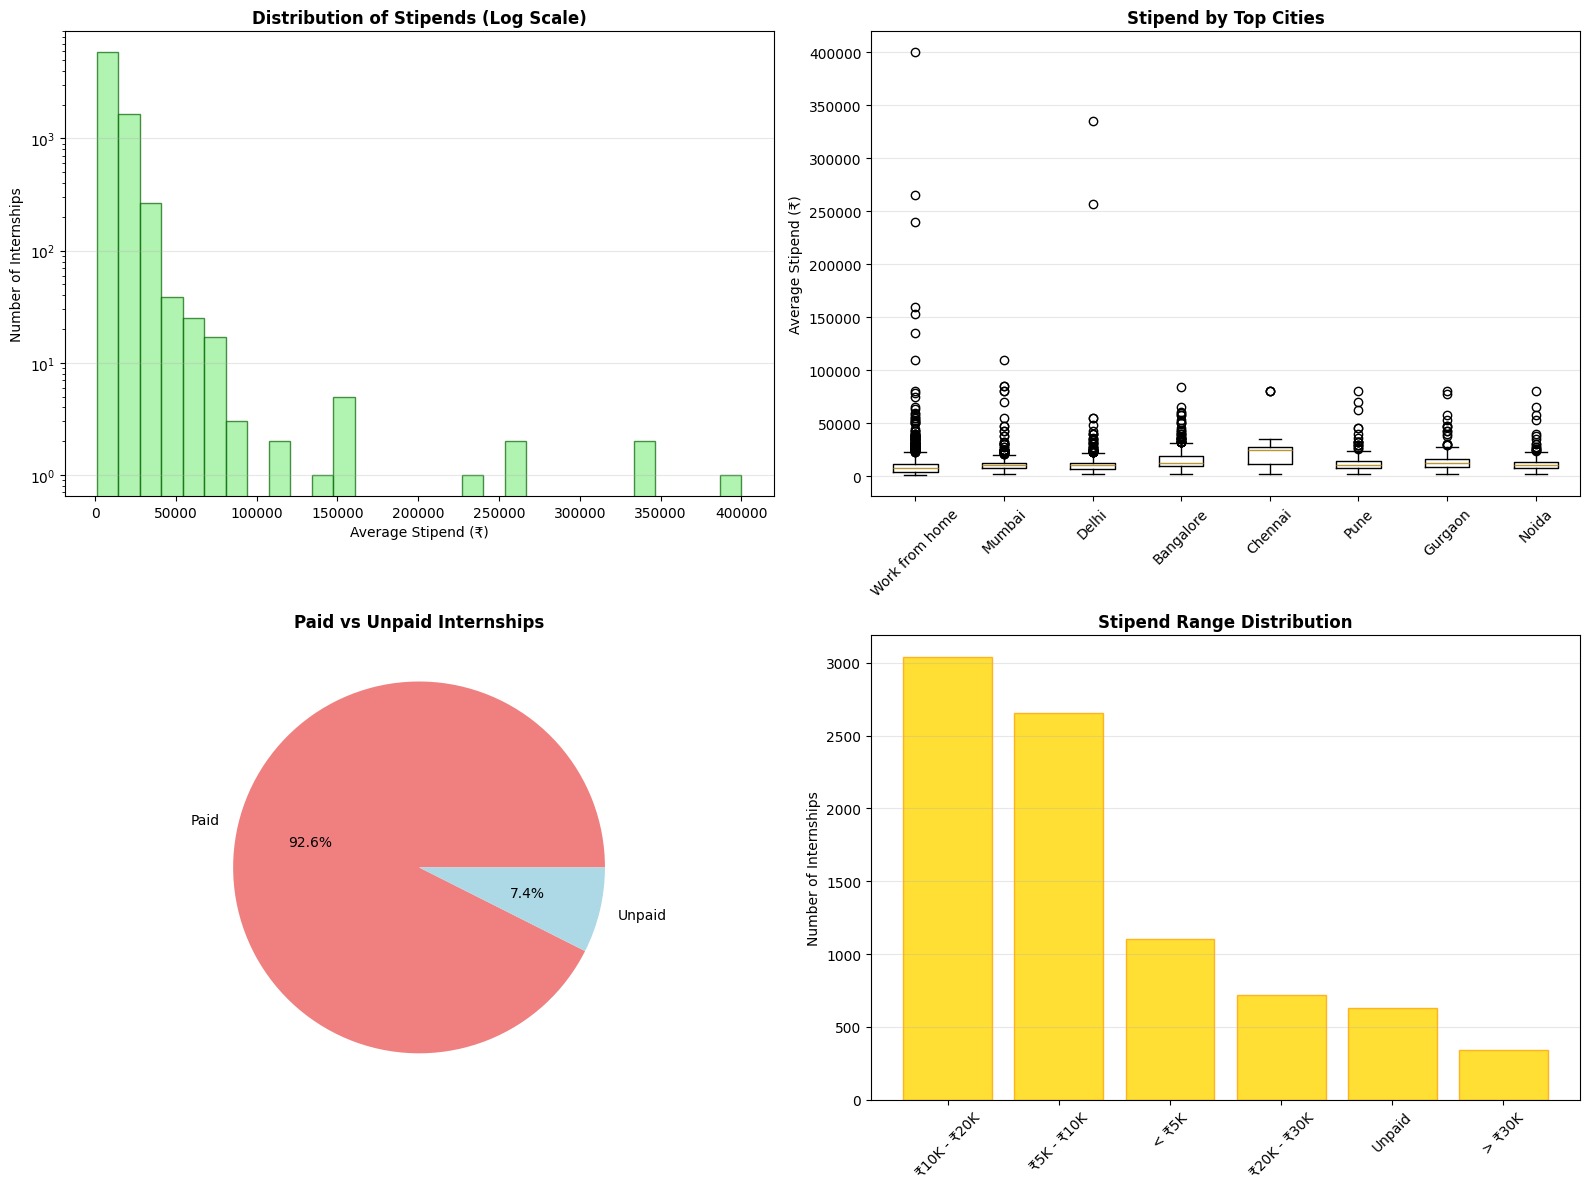

In [142]:
# Visualize stipend distribution
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Histogram of stipends (log scale to handle skewness)
paid_stipends = df[df['avg_stipend'] > 0]['avg_stipend']
ax1.hist(paid_stipends, bins=30, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
ax1.set_title('Distribution of Stipends (Log Scale)', fontweight='bold')
ax1.set_xlabel('Average Stipend (₹)')
ax1.set_ylabel('Number of Internships')
ax1.set_yscale('log')
ax1.grid(axis='y', alpha=0.3)

# Box plot by location (top cities)
top_cities = df['Location'].value_counts().head(8).index
city_stipend_data = []
city_labels = []
for city in top_cities:
    city_stipends = df[(df['Location'] == city) & (df['avg_stipend'] > 0)]['avg_stipend']
    if len(city_stipends) > 0:
        city_stipend_data.append(city_stipends)
        city_labels.append(city)

ax2.boxplot(city_stipend_data, labels=city_labels)
ax2.set_title('Stipend by Top Cities', fontweight='bold')
ax2.set_ylabel('Average Stipend (₹)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Paid vs Unpaid
paid_unpaid = ['Paid' if x > 0 else 'Unpaid' for x in df['avg_stipend']]
paid_counts = pd.Series(paid_unpaid).value_counts()
colors = ['lightcoral', 'lightblue']
ax3.pie(paid_counts.values, labels=paid_counts.index, autopct='%1.1f%%', colors=colors)
ax3.set_title('Paid vs Unpaid Internships', fontweight='bold')

# Stipend ranges
stipend_ranges = []
for stipend in df['avg_stipend']:
    if stipend == 0:
        stipend_ranges.append('Unpaid')
    elif stipend < 5000:
        stipend_ranges.append('< ₹5K')
    elif stipend < 10000:
        stipend_ranges.append('₹5K - ₹10K')
    elif stipend < 20000:
        stipend_ranges.append('₹10K - ₹20K')
    elif stipend < 30000:
        stipend_ranges.append('₹20K - ₹30K')
    else:
        stipend_ranges.append('> ₹30K')

range_counts = pd.Series(stipend_ranges).value_counts()
ax4.bar(range_counts.index, range_counts.values, color='gold', edgecolor='orange', alpha=0.8)
ax4.set_title('Stipend Range Distribution', fontweight='bold')
ax4.set_ylabel('Number of Internships')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## ⏱️ Duration & Timeline Analysis

Let's see how long these internships typically last and when they're supposed to start.

⏳ Duration Analysis:
------------------------------
Most common durations:
6 Months       : 3226 ( 38.0%)
3 Months       : 3113 ( 36.7%)
2 Months       :  837 (  9.9%)
1 Month        :  426 (  5.0%)
4 Months       :  413 (  4.9%)
Not Available  :  208 (  2.5%)
5 Months       :   54 (  0.6%)
2 Weeks        :   46 (  0.5%)
1 Week         :   32 (  0.4%)
4 Weeks        :   27 (  0.3%)

📅 Start Date Analysis:
------------------------------
Most common start dates:
Immediately    : 8139 ( 95.9%)
Not Available  :  275 (  3.2%)
2. can start the work from home job/internship between 1st Dec'25 and 31st Dec'25:   24 (  0.3%)
Goldman Sachs, founded in 1869 by Marcus Goldman, is a leading global investment banking and financial services firm headquartered in New York City. With a market capitalization of approximately $140 billion and annual revenue of $48 billion in 2023, Goldman Sachs specializes in investment banking, asset management, and securities trading. In India, the firm operates a sign

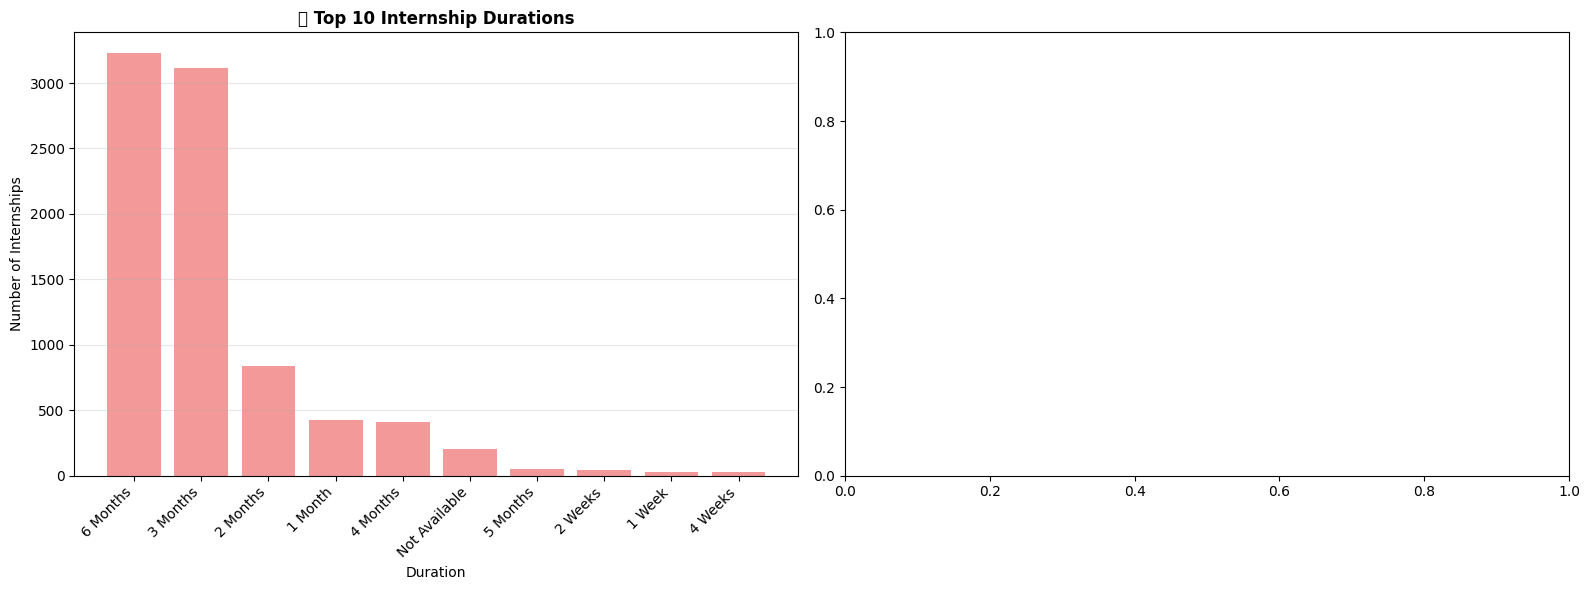

In [143]:
# Analyze duration patterns
print("⏳ Duration Analysis:")
print("-" * 30)

duration_counts = df['Duration'].value_counts()
print("Most common durations:")
for duration, count in duration_counts.head(10).items():
    percentage = (count / len(df)) * 100
    print(f"{duration:<15}: {count:>4} ({percentage:5.1f}%)")

# Analyze start dates
print(f"\n📅 Start Date Analysis:")
print("-" * 30)
start_date_counts = df['Start Date'].value_counts()
print("Most common start dates:")
for date, count in start_date_counts.head(8).items():
    percentage = (count / len(df)) * 100
    print(f"{date:<15}: {count:>4} ({percentage:5.1f}%)")

# Create visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Duration distribution
top_durations = duration_counts.head(10)
ax1.bar(range(len(top_durations)), top_durations.values, color='lightcoral', alpha=0.8)
ax1.set_title('⏱️ Top 10 Internship Durations', fontweight='bold')
ax1.set_xlabel('Duration')
ax1.set_ylabel('Number of Internships')
ax1.set_xticks(range(len(top_durations)))
ax1.set_xticklabels(top_durations.index, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 💼 Profile & Company Analysis

What kind of roles are companies offering? Let's see the most popular profiles and companies hiring.

👔 Most Popular Internship Profiles:
---------------------------------------------
Business Development (Sales)       :  650 ( 7.7%)
Digital Marketing                  :  329 ( 3.9%)
Human Resources (HR)               :  324 ( 3.8%)
Content and Social Media Marketing :  321 ( 3.8%)
Graphic Design                     :  312 ( 3.7%)
Social Media Marketing             :  308 ( 3.6%)
Video Editing/Making               :  307 ( 3.6%)
Marketing                          :  210 ( 2.5%)
Nothing                            :  207 ( 2.4%)
Sales and Marketing                :  168 ( 2.0%)
Content Writing                    :  134 ( 1.6%)
Operations                         :   89 ( 1.0%)
Full Stack Development             :   89 ( 1.0%)
Search Engine Optimization (SEO)   :   85 ( 1.0%)
Telecalling                        :   77 ( 0.9%)

🏢 Top Companies Hiring:
-----------------------------------
Tisteps Private Limited            :  292 ( 3.4%)
Nothing                            :  207 ( 2.4%)
BNM Bus

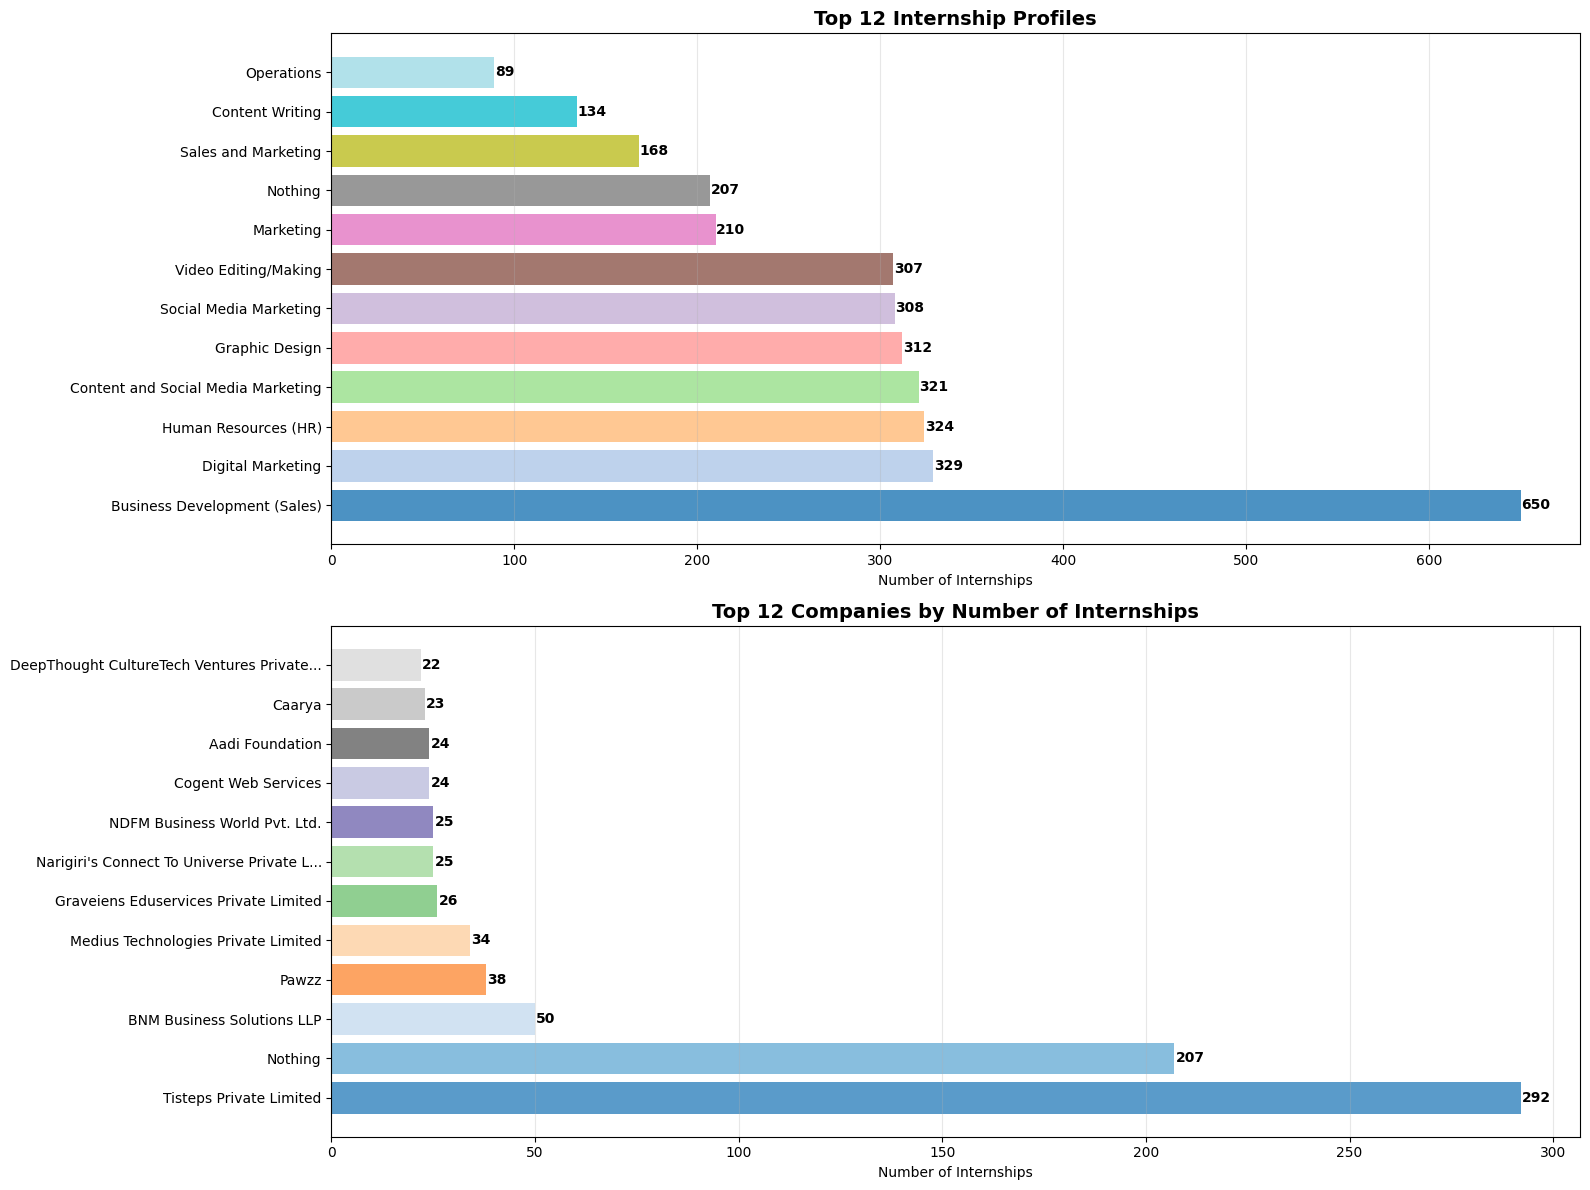

In [144]:
# Analyze profiles
print("👔 Most Popular Internship Profiles:")
print("-" * 45)

profile_counts = df['profile'].value_counts()
for profile, count in profile_counts.head(15).items():
    percentage = (count / len(df)) * 100
    print(f"{profile:<35}: {count:>4} ({percentage:4.1f}%)")

# Analyze companies
print(f"\n🏢 Top Companies Hiring:")
print("-" * 35)

company_counts = df['company'].value_counts()
for company, count in company_counts.head(15).items():
    percentage = (count / len(df)) * 100
    # Truncate long company names for better display
    display_name = company[:30] + "..." if len(company) > 30 else company
    print(f"{display_name:<35}: {count:>4} ({percentage:4.1f}%)")

print(f"\nTotal unique companies: {len(company_counts)}")
print(f"Total unique profiles: {len(profile_counts)}")

# Create word cloud style visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Top profiles
top_profiles = profile_counts.head(12)
colors1 = plt.cm.tab20(np.linspace(0, 1, len(top_profiles)))
bars1 = ax1.barh(range(len(top_profiles)), top_profiles.values, color=colors1, alpha=0.8)
ax1.set_title('Top 12 Internship Profiles', fontweight='bold', fontsize=14)
ax1.set_xlabel('Number of Internships')
ax1.set_yticks(range(len(top_profiles)))
ax1.set_yticklabels([p[:40] + "..." if len(p) > 40 else p for p in top_profiles.index])
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', ha='left', va='center', fontweight='bold')

# Top companies
top_companies = company_counts.head(12)
colors2 = plt.cm.tab20c(np.linspace(0, 1, len(top_companies)))
bars2 = ax2.barh(range(len(top_companies)), top_companies.values, color=colors2, alpha=0.8)
ax2.set_title('Top 12 Companies by Number of Internships', fontweight='bold', fontsize=14)
ax2.set_xlabel('Number of Internships')
ax2.set_yticks(range(len(top_companies)))
ax2.set_yticklabels([c[:40] + "..." if len(c) > 40 else c for c in top_companies.index])
ax2.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax2.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 🎯 Skills & Requirements Analysis

This is super important! Let's see what skills are in highest demand. Time to update that resume! 📝

In [145]:
# Extract and analyze skills
all_skills = []

for skills_str in df['Skills'].dropna():
    if skills_str != 'Not Specified':
        # Split by comma and clean up
        skills_list = [skill.strip() for skill in str(skills_str).split(',')]
        all_skills.extend(skills_list)

# Count skill frequency
from collections import Counter
skill_counts = Counter(all_skills)

print("🎯 Most In-Demand Skills:")
print("-" * 40)

top_skills = skill_counts.most_common(20)
for skill, count in top_skills:
    percentage = (count / len(df)) * 100
    print(f"{skill:<35}: {count:>4} ({percentage:4.1f}%)")

🎯 Most In-Demand Skills:
----------------------------------------
English Proficiency (Spoken)       : 2548 (30.0%)
English Proficiency (Written)      : 2015 (23.8%)
Effective Communication            : 1868 (22.0%)
MS-Excel                           : 1439 (17.0%)
Social Media Marketing             : 1242 (14.6%)
Digital Marketing                  : 1077 (12.7%)
MS-Office                          :  842 ( 9.9%)
Adobe Photoshop                    :  769 ( 9.1%)
Video Editing                      :  666 ( 7.9%)
Canva                              :  635 ( 7.5%)
Email Marketing                    :  635 ( 7.5%)
Adobe Illustrator                  :  543 ( 6.4%)
Creative Writing                   :  538 ( 6.3%)
Interpersonal skills               :  535 ( 6.3%)
Instagram Marketing                :  533 ( 6.3%)
Search Engine Optimization (SEO)   :  523 ( 6.2%)
Sales                              :  522 ( 6.2%)
Adobe Premiere Pro                 :  433 ( 5.1%)
Content Writing                   

## 🎁 Perks & Benefits Analysis

Let's see what additional benefits companies are offering. Some perks can be really valuable!

In [146]:
# Analyze perks and benefits
all_perks = []

for perks_str in df['Perks'].dropna():
    if perks_str != 'Not Available' and perks_str != 'Not Specified':
        # Split by comma and clean up
        perks_list = [perk.strip() for perk in str(perks_str).split(',')]
        all_perks.extend(perks_list)

# Count perk frequency
perk_counts = Counter(all_perks)

print("🎁 Most Common Perks & Benefits:")
print("-" * 40)

if len(perk_counts) > 0:
    top_perks = perk_counts.most_common(15)
    for perk, count in top_perks:
        percentage = (count / len(df)) * 100
        print(f"{perk:<30}: {count:>4} ({percentage:4.1f}%)")
else:
    print("No specific perks data available")

🎁 Most Common Perks & Benefits:
----------------------------------------
Certificate                   : 7243 (85.4%)
Letter Of Recommendation      : 5736 (67.6%)
Flexible                      : 4053 (47.8%)
5 Days A Week                 : 2871 (33.8%)
Mentorship                    :  447 ( 5.3%)


## 🔍 Cross-Analysis & Insights

Let's dig deeper and find some interesting patterns by combining different variables!

In [147]:
# Average stipend by location
print("💰 Average Stipend by Location (Top Cities):")
print("-" * 50)

location_stipend = df[df['avg_stipend'] > 0].groupby('Location')['avg_stipend'].agg(['mean', 'count']).round(0)
location_stipend = location_stipend[location_stipend['count'] >= 10].sort_values('mean', ascending=False)

for location, data in location_stipend.head(10).iterrows():
    print(f"{location:<20}: ₹{data['mean']:>6.0f}/month (from {data['count']:>3} internships)")

# Average stipend by profile
print(f"\n💼 Average Stipend by Profile (Top Profiles):")
print("-" * 50)

profile_stipend = df[df['avg_stipend'] > 0].groupby('profile')['avg_stipend'].agg(['mean', 'count']).round(0)
profile_stipend = profile_stipend[profile_stipend['count'] >= 5].sort_values('mean', ascending=False)

for profile, data in profile_stipend.head(12).iterrows():
    display_profile = profile[:30] + "..." if len(profile) > 30 else profile
    print(f"{display_profile:<35}: ₹{data['mean']:>6.0f}/month (from {data['count']:>3} internships)")

# Work from home vs Office analysis
print(f"\n🏠 Work From Home vs Office-based:")
print("-" * 40)

wfh_mask = df['Location'].str.contains('Work from home', case=False, na=False)
wfh_count = wfh_mask.sum()
office_count = len(df) - wfh_count

wfh_avg_stipend = df[wfh_mask & (df['avg_stipend'] > 0)]['avg_stipend'].mean()
office_avg_stipend = df[~wfh_mask & (df['avg_stipend'] > 0)]['avg_stipend'].mean()

print(f"Work from Home    : {wfh_count:>4} internships (Avg Stipend: ₹{wfh_avg_stipend:.0f})")
print(f"Office-based      : {office_count:>4} internships (Avg Stipend: ₹{office_avg_stipend:.0f})")

# Duration vs Stipend analysis
print(f"\n⏱️ Duration vs Average Stipend:")
print("-" * 40)

duration_stipend = df[df['avg_stipend'] > 0].groupby('Duration')['avg_stipend'].agg(['mean', 'count']).round(0)
duration_stipend = duration_stipend[duration_stipend['count'] >= 10].sort_values('mean', ascending=False)

for duration, data in duration_stipend.head(8).iterrows():
    print(f"{duration:<15}: ₹{data['mean']:>6.0f}/month (from {data['count']:>3} internships)")

💰 Average Stipend by Location (Top Cities):
--------------------------------------------------
Ulhasnagar          : ₹ 33875/month (from 12.0 internships)
Secunderabad        : ₹ 21694/month (from 17.0 internships)
Chennai             : ₹ 20760/month (from 546.0 internships)
Chandigarh          : ₹ 18625/month (from 22.0 internships)
Mangalore           : ₹ 16300/month (from 10.0 internships)
Coimbatore          : ₹ 16115/month (from 13.0 internships)
Bangalore           : ₹ 15131/month (from 694.0 internships)
Ahmedabad           : ₹ 14750/month (from 20.0 internships)
Faridabad           : ₹ 14588/month (from 90.0 internships)
Gurgaon             : ₹ 13675/month (from 404.0 internships)

💼 Average Stipend by Profile (Top Profiles):
--------------------------------------------------
Blockchain Development             : ₹ 64950/month (from 5.0 internships)
Construction Site Engineering      : ₹ 32333/month (from 6.0 internships)
Manual Testing                     : ₹ 30500/month (from 

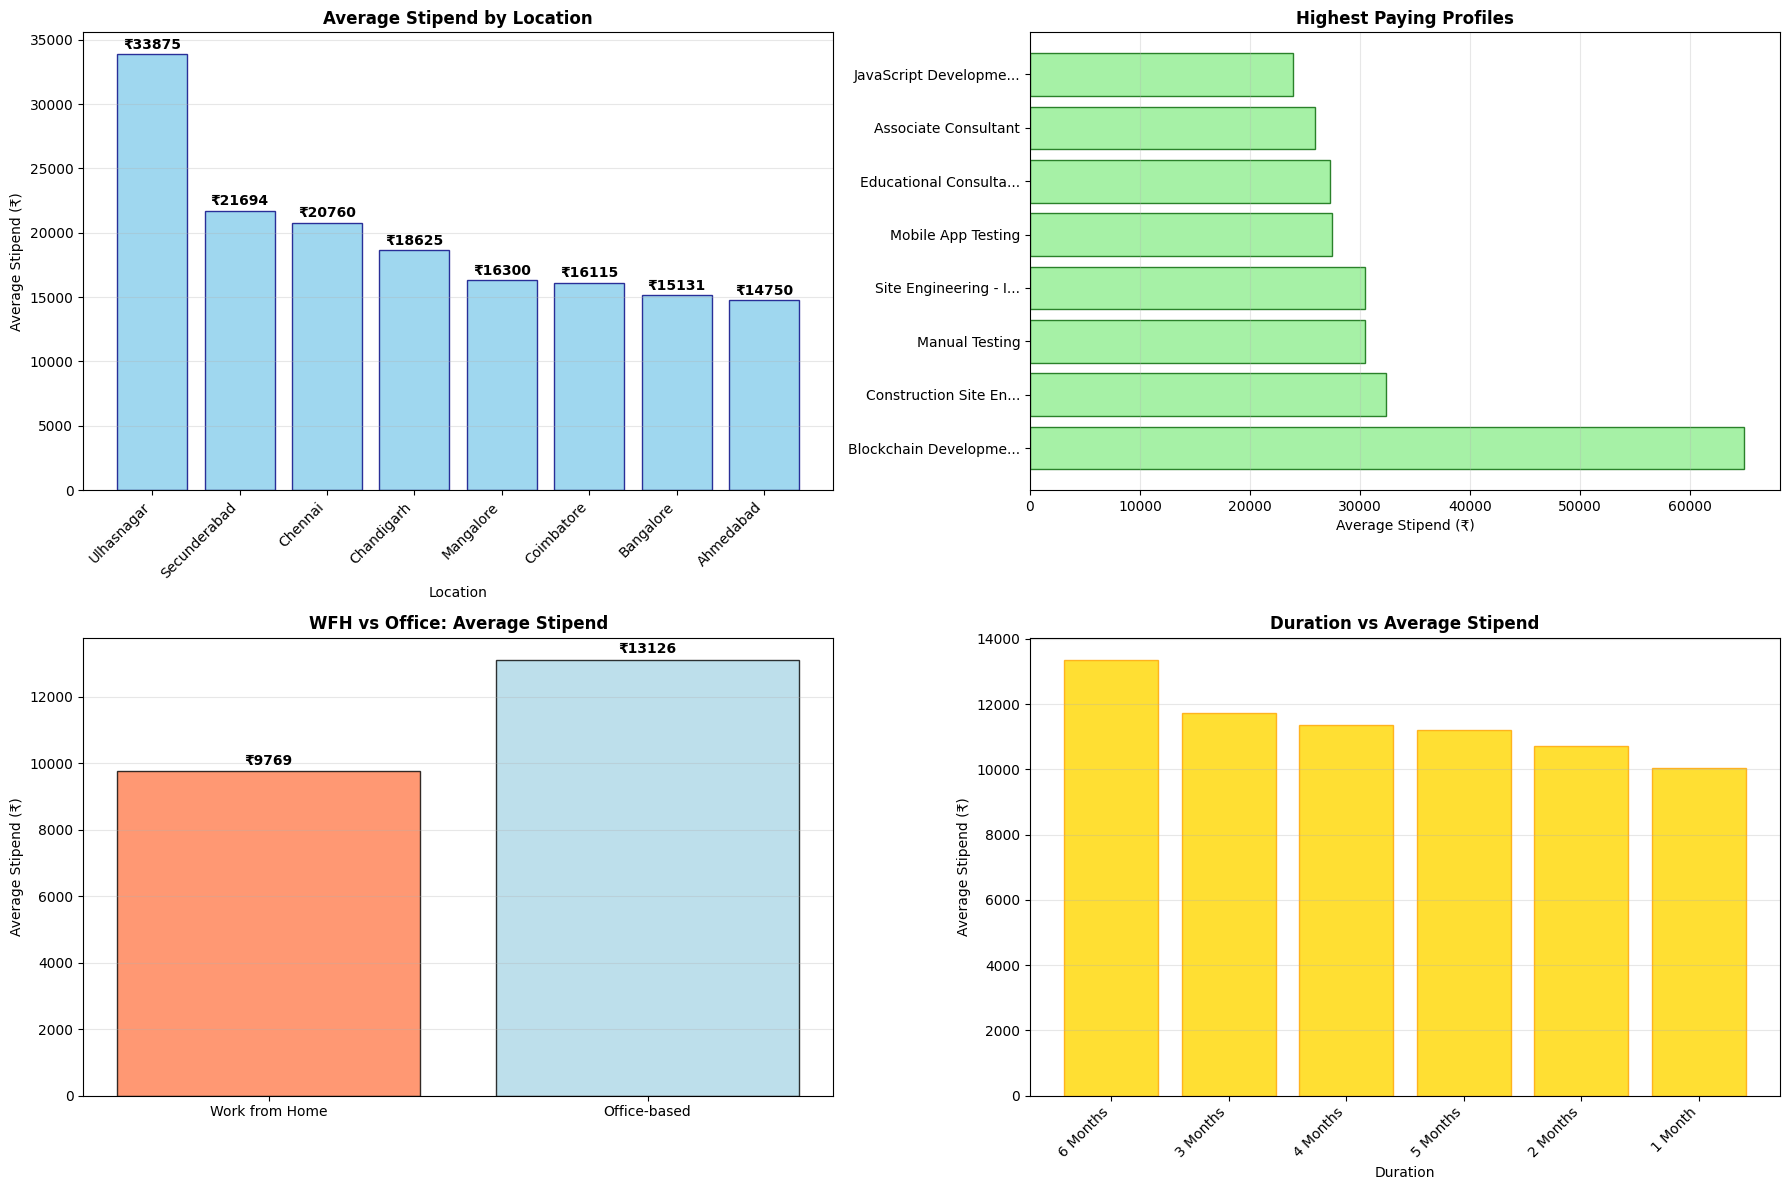

In [148]:
# Create comprehensive comparison visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# Location vs Stipend
top_locations_stipend = location_stipend.head(8)
bars1 = ax1.bar(range(len(top_locations_stipend)), top_locations_stipend['mean'], 
                color='skyblue', alpha=0.8, edgecolor='navy')
ax1.set_title('Average Stipend by Location', fontweight='bold')
ax1.set_xlabel('Location')
ax1.set_ylabel('Average Stipend (₹)')
ax1.set_xticks(range(len(top_locations_stipend)))
ax1.set_xticklabels(top_locations_stipend.index, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 200,
             f'₹{int(height)}', ha='center', va='bottom', fontweight='bold')

# Profile vs Stipend (top paying)
top_profiles_stipend = profile_stipend.head(8)
bars2 = ax2.barh(range(len(top_profiles_stipend)), top_profiles_stipend['mean'], 
                 color='lightgreen', alpha=0.8, edgecolor='darkgreen')
ax2.set_title('Highest Paying Profiles', fontweight='bold')
ax2.set_xlabel('Average Stipend (₹)')
ax2.set_yticks(range(len(top_profiles_stipend)))
ax2.set_yticklabels([p[:20] + "..." if len(p) > 20 else p for p in top_profiles_stipend.index])
ax2.grid(axis='x', alpha=0.3)

# WFH vs Office comparison
wfh_office_data = [wfh_avg_stipend, office_avg_stipend]
wfh_office_labels = ['Work from Home', 'Office-based']
colors = ['coral', 'lightblue']
bars3 = ax3.bar(wfh_office_labels, wfh_office_data, color=colors, alpha=0.8, edgecolor='black')
ax3.set_title('WFH vs Office: Average Stipend', fontweight='bold')
ax3.set_ylabel('Average Stipend (₹)')
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars3):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'₹{int(height)}', ha='center', va='bottom', fontweight='bold')

# Duration vs Stipend
top_duration_stipend = duration_stipend.head(6)
bars4 = ax4.bar(range(len(top_duration_stipend)), top_duration_stipend['mean'], 
                color='gold', alpha=0.8, edgecolor='orange')
ax4.set_title('Duration vs Average Stipend', fontweight='bold')
ax4.set_xlabel('Duration')
ax4.set_ylabel('Average Stipend (₹)')
ax4.set_xticks(range(len(top_duration_stipend)))
ax4.set_xticklabels(top_duration_stipend.index, rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 Key Findings & Summary

Let me summarize the most interesting insights from this analysis!

In [149]:
# Generate comprehensive summary
print("🎯 INTERNSHALA INTERNSHIP MARKET INSIGHTS - 2025")

print(f"\n📊 DATASET OVERVIEW:")
print(f"   • Total internships analyzed: {len(df):,}")
print(f"   • Unique companies: {df['company'].nunique():,}")
print(f"   • Unique profiles: {df['profile'].nunique():,}")
print(f"   • Data scraped from: Internshala portal in 2025")

print(f"\n🌍 GEOGRAPHIC INSIGHTS:")
top_location = df['Location'].value_counts().index[0]
top_location_count = df['Location'].value_counts().iloc[0]
print(f"   • Hottest location: {top_location} ({top_location_count} opportunities)")
print(f"   • Work from home: {wfh_count} internships ({wfh_count/len(df)*100:.1f}%)")
print(f"   • Major hubs: Bangalore, Mumbai, Delhi, Pune dominate")

print(f"\n💰 COMPENSATION INSIGHTS:")
paid_internships = len(df[df['avg_stipend'] > 0])
median_stipend = df[df['avg_stipend'] > 0]['avg_stipend'].median()
print(f"   • Paid internships: {paid_internships} ({paid_internships/len(df)*100:.1f}%)")
print(f"   • Median stipend: ₹{median_stipend:,.0f}/month")
print(f"   • Best paying location: {location_stipend.index[0]} (₹{location_stipend.iloc[0]['mean']:,.0f})")
print(f"   • WFH vs Office: ₹{wfh_avg_stipend:.0f} vs ₹{office_avg_stipend:.0f}")

print(f"\n💼 PROFILE INSIGHTS:")
top_profile = df['profile'].value_counts().index[0]
top_profile_count = df['profile'].value_counts().iloc[0]
print(f"   • Most common role: {top_profile} ({top_profile_count} openings)")
print(f"   • Highest paying: {profile_stipend.index[0]} (₹{profile_stipend.iloc[0]['mean']:,.0f})")

# print(f"\n🎯 SKILLS INSIGHTS:")
# if len(skill_counts) > 0:
#     top_skill = skill_counts.most_common(1)[0]
#     print(f"   • Most demanded skill: {top_skill[0]} ({top_skill[1]} mentions)")
#     print(f"   • Key skills: Communication, MS Office, Digital Marketing")
# else:
#     print(f"   • Skills data available in detailed breakdown")

# print(f"\n⏱️ DURATION INSIGHTS:")
# common_duration = df['Duration'].value_counts().index[0]
# common_duration_count = df['Duration'].value_counts().iloc[0]
# print(f"   • Most common duration: {common_duration} ({common_duration_count} internships)")
# print(f"   • Immediate start: {df[df['Start Date'] == 'Immediately'].shape[0]} positions")

# print(f"\n🏢 COMPANY INSIGHTS:")
# top_company = df['company'].value_counts().index[0]
# top_company_count = df['company'].value_counts().iloc[0]
# print(f"   • Top hiring company: {top_company} ({top_company_count} openings)")
# print(f"   • Many companies offer single internships (diverse opportunities)")

# print("\n" + "=" * 60)
# print("💡 RECOMMENDATIONS FOR STUDENTS:")
# print("   1. Focus on communication & MS Office skills")
# print("   2. Consider WFH opportunities for flexibility")
# print("   3. Bangalore & Mumbai offer highest stipends")
# print("   4. Marketing & Tech profiles are in high demand")
# print("   5. Most internships start immediately - be ready!")
# print("=" * 60)

🎯 INTERNSHALA INTERNSHIP MARKET INSIGHTS - 2025

📊 DATASET OVERVIEW:
   • Total internships analyzed: 8,483
   • Unique companies: 5,114
   • Unique profiles: 1,977
   • Data scraped from: Internshala portal in 2025

🌍 GEOGRAPHIC INSIGHTS:
   • Hottest location: Work from home (2647 opportunities)
   • Work from home: 2647 internships (31.2%)
   • Major hubs: Bangalore, Mumbai, Delhi, Pune dominate

💰 COMPENSATION INSIGHTS:
   • Paid internships: 7853 (92.6%)
   • Median stipend: ₹10,000/month
   • Best paying location: Ulhasnagar (₹33,875)
   • WFH vs Office: ₹9769 vs ₹13126

💼 PROFILE INSIGHTS:
   • Most common role: Business Development (Sales) (650 openings)
   • Highest paying: Blockchain Development (₹64,950)
